# CausalPy-Inspired Cross-Sectional Methods For Commercial Analytics

This notebook adapts the cross-sectional CausalPy example families to commercial
analytics settings:

1. Regression discontinuity for a threshold-based offer.
2. Instrumental variables for endogenous ad exposure.
3. Inverse propensity weighting for observational targeting.

The implementation is intentionally lightweight. It teaches the design logic
before asking students to use a heavier Bayesian package.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(123)


## 1. Regression Discontinuity: Free Shipping Threshold

Use this design when the treatment is assigned by a cutoff. The estimate is a
local effect at the threshold, not a global estimate for all customers.

Commercial translation: estimate whether qualifying for free shipping at a
cart-value threshold increases order margin among customers near the rule.

### Method Explanation

Regression discontinuity uses a rule-created cutoff as a local experiment. The
running variable is the quantity that decides treatment. Here it is cart value
minus the free-shipping threshold. Customers just below and just above zero are
assumed to be similar, except that customers above zero qualify for the offer.

The model estimates a jump at the cutoff after controlling for the smooth
relationship between cart value and margin. Because the effect is local, the
bandwidth matters. A narrow bandwidth gives a more local comparison but fewer
customers. A wide bandwidth gives more precision but may compare customers who
are no longer similar.

Read the estimate as:

```text
the margin effect of free-shipping eligibility for customers near the threshold
```

Do not read it as the effect of free shipping for all customers. A shopper with
a cart far below the threshold may respond differently from a shopper already
near the cutoff.

Before using RD, inspect a binned scatterplot, test multiple bandwidths, allow
different slopes on each side of the cutoff, and look for bunching or
manipulation around the rule.


In [2]:
n_customers = 6_000
cart_value_minus_threshold = rng.normal(0, 18, n_customers)
loyalty_member = rng.binomial(1, 0.38, n_customers)
mobile_session = rng.binomial(1, 0.54, n_customers)
eligible_for_free_shipping = (cart_value_minus_threshold >= 0).astype(int)

order_margin = (
    42
    + 0.85 * cart_value_minus_threshold
    - 0.012 * cart_value_minus_threshold ** 2
    + 7.5 * eligible_for_free_shipping
    + 4.0 * loyalty_member
    - 2.2 * mobile_session
    + rng.normal(0, 9.0, n_customers)
)

rd_df = pd.DataFrame(
    {
        "cart_value_minus_threshold": cart_value_minus_threshold,
        "eligible_for_free_shipping": eligible_for_free_shipping,
        "loyalty_member": loyalty_member,
        "mobile_session": mobile_session,
        "order_margin": order_margin,
    }
)

rd_df.head()


,cart_value_minus_threshold,eligible_for_free_shipping,loyalty_member,mobile_session,order_margin
0,-17.804184,0,0,1,11.717886
1,-6.620160,0,0,0,41.894671
2,23.182655,1,1,1,68.478909
3,3.491540,1,1,1,43.115195
4,16.564156,1,0,0,64.783580


In [3]:
bandwidth = 16
local_rd = rd_df[rd_df["cart_value_minus_threshold"].abs() <= bandwidth].copy()

rd_model = smf.ols(
    "order_margin ~ eligible_for_free_shipping + cart_value_minus_threshold + "
    "eligible_for_free_shipping:cart_value_minus_threshold + loyalty_member + mobile_session",
    data=local_rd,
).fit(cov_type="HC1")

rd_summary = pd.Series(
    {
        "bandwidth": bandwidth,
        "customers_in_local_window": len(local_rd),
        "estimated_threshold_effect": rd_model.params["eligible_for_free_shipping"],
        "std_error": rd_model.bse["eligible_for_free_shipping"],
        "ci_lower": rd_model.conf_int().loc["eligible_for_free_shipping", 0],
        "ci_upper": rd_model.conf_int().loc["eligible_for_free_shipping", 1],
        "true_effect_in_simulation": 7.5,
    }
)

rd_summary.to_frame("value")


,value
bandwidth,16.000000
customers_in_local_window,3737.000000
estimated_threshold_effect,8.208325
std_error,0.560224
ci_lower,7.110306
ci_upper,9.306343
true_effect_in_simulation,7.500000


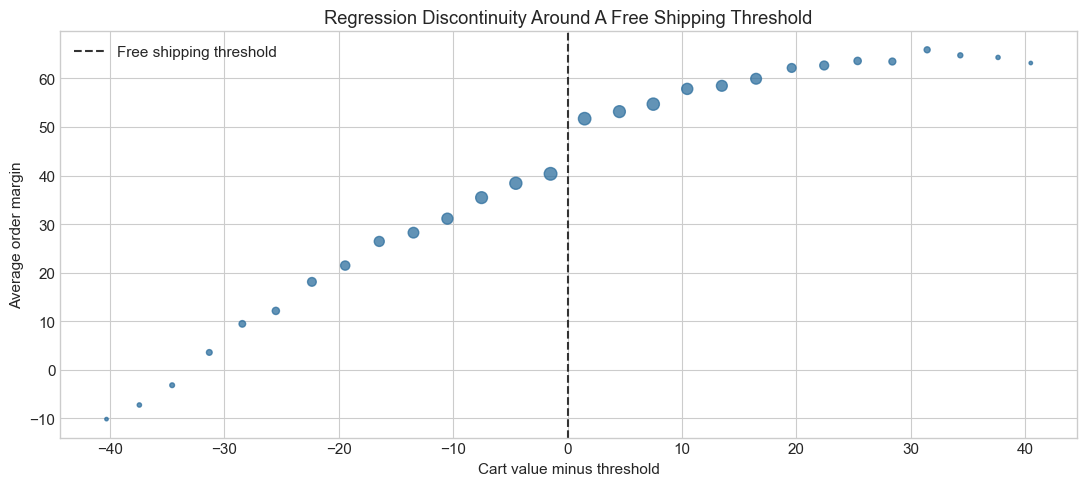

In [4]:
bin_edges = np.arange(-42, 43, 3)
rd_df["cart_bin"] = pd.cut(rd_df["cart_value_minus_threshold"], bins=bin_edges)
binned = (
    rd_df.groupby("cart_bin", observed=True)
    .agg(
        bin_midpoint=("cart_value_minus_threshold", "mean"),
        mean_margin=("order_margin", "mean"),
        n=("order_margin", "size"),
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(binned["bin_midpoint"], binned["mean_margin"], s=binned["n"] / 5, alpha=0.75, color="#2E6F9E")
ax.axvline(0, color="#333333", linestyle="--", label="Free shipping threshold")
ax.set_title("Regression Discontinuity Around A Free Shipping Threshold")
ax.set_xlabel("Cart value minus threshold")
ax.set_ylabel("Average order margin")
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
sensitivity_records = []
for bw in [8, 12, 16, 22, 30]:
    sample = rd_df[rd_df["cart_value_minus_threshold"].abs() <= bw].copy()
    model = smf.ols(
        "order_margin ~ eligible_for_free_shipping + cart_value_minus_threshold + "
        "eligible_for_free_shipping:cart_value_minus_threshold + loyalty_member + mobile_session",
        data=sample,
    ).fit(cov_type="HC1")
    sensitivity_records.append(
        {
            "bandwidth": bw,
            "n": len(sample),
            "estimate": model.params["eligible_for_free_shipping"],
            "ci_lower": model.conf_int().loc["eligible_for_free_shipping", 0],
            "ci_upper": model.conf_int().loc["eligible_for_free_shipping", 1],
        }
    )

pd.DataFrame(sensitivity_records)


,bandwidth,n,estimate,ci_lower,ci_upper
0,8,2056,9.298273,7.777440,10.819107
1,12,2940,7.965871,6.708764,9.222978
2,16,3737,8.208325,7.110306,9.306343
3,22,4662,8.077624,7.104665,9.050583
4,30,5424,7.995717,7.123324,8.868110


## 2. Instrumental Variables: Endogenous Ad Exposure

Use this design when treatment exposure is endogenous. A valid instrument moves
treatment exposure but has no direct path to the outcome except through that
treatment.

Commercial translation: estimate the revenue effect of impressions when high
intent users are more likely to receive impressions. The simulated instrument is
an auction pacing rule that randomly increases delivery opportunity.

### Method Explanation

Instrumental variables are useful when the treatment is confounded by intent.
In advertising, high-intent users often receive more impressions, so a naive
regression of revenue on impressions can mistake intent for ad effect.

An instrument solves a narrower problem. It creates variation in impressions
that is plausibly unrelated to hidden purchase intent. In this simulation,
`auction_pacing_win` changes delivery opportunity and therefore impressions,
but it does not directly change revenue in the data-generating process.

The two stages are:

1. Predict impressions from the instrument and observed controls.
2. Predict revenue from the instrument-driven part of impressions.

The IV estimate is not always the average effect for everyone. It is the effect
for the users whose impressions were moved by the instrument. In a business
memo, name that population instead of pretending it is automatically universal.

Before using IV, check instrument relevance, first-stage strength, and the
exclusion argument. The exclusion restriction cannot be fully proven from data.
It must be defended from how the business or platform rule works.


In [6]:
n_users = 7_000
auction_pacing_win = rng.binomial(1, 0.5, n_users)
seasonality_score = rng.normal(0, 1, n_users)
unobserved_purchase_intent = rng.normal(0, 1, n_users)

true_impression_effect = 0.42
impressions = (
    35
    + 19 * auction_pacing_win
    + 7 * seasonality_score
    + 24 * unobserved_purchase_intent
    + rng.normal(0, 10, n_users)
)
revenue = (
    18
    + true_impression_effect * impressions
    + 31 * unobserved_purchase_intent
    + 4 * seasonality_score
    + rng.normal(0, 18, n_users)
)

iv_df = pd.DataFrame(
    {
        "auction_pacing_win": auction_pacing_win,
        "seasonality_score": seasonality_score,
        "impressions": impressions,
        "revenue": revenue,
    }
)

naive_model = smf.ols("revenue ~ impressions + seasonality_score", data=iv_df).fit(cov_type="HC1")
first_stage = smf.ols("impressions ~ auction_pacing_win + seasonality_score", data=iv_df).fit(cov_type="HC1")
iv_df["predicted_impressions"] = first_stage.fittedvalues
second_stage = smf.ols("revenue ~ predicted_impressions + seasonality_score", data=iv_df).fit(cov_type="HC1")

first_stage_f = float(first_stage.f_test("auction_pacing_win = 0").fvalue)

iv_summary = pd.Series(
    {
        "true_impression_effect": true_impression_effect,
        "naive_ols_estimate": naive_model.params["impressions"],
        "iv_2sls_estimate": second_stage.params["predicted_impressions"],
        "iv_std_error": second_stage.bse["predicted_impressions"],
        "first_stage_effect_of_instrument": first_stage.params["auction_pacing_win"],
        "first_stage_f_stat": first_stage_f,
    }
)

iv_summary.to_frame("value")


,value
true_impression_effect,0.420000
naive_ols_estimate,1.392930
iv_2sls_estimate,0.459547
iv_std_error,0.055080
first_stage_effect_of_instrument,19.499108
first_stage_f_stat,993.969095


/var/folders/hc/r468t5c13sl_7pb7py3qgcg00000gn/T/ipykernel_39361/1683179056.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


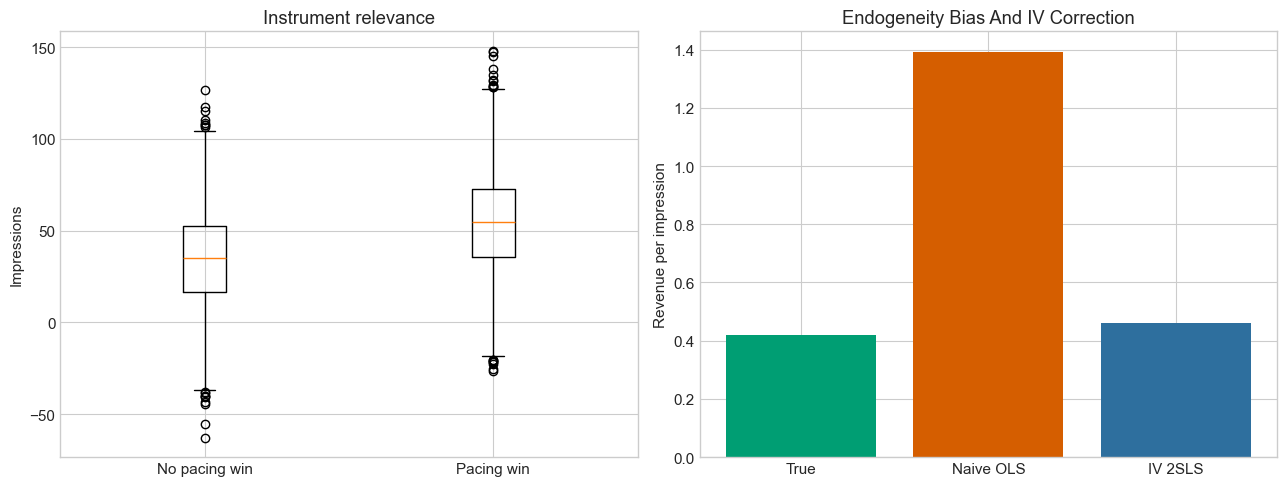

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot(
    [
        iv_df.loc[iv_df["auction_pacing_win"].eq(0), "impressions"],
        iv_df.loc[iv_df["auction_pacing_win"].eq(1), "impressions"],
    ],
    labels=["No pacing win", "Pacing win"],
)
axes[0].set_title("Instrument relevance")
axes[0].set_ylabel("Impressions")

axes[1].bar(
    ["True", "Naive OLS", "IV 2SLS"],
    [true_impression_effect, naive_model.params["impressions"], second_stage.params["predicted_impressions"]],
    color=["#009E73", "#D55E00", "#2E6F9E"],
)
axes[1].set_title("Endogeneity Bias And IV Correction")
axes[1].set_ylabel("Revenue per impression")
plt.tight_layout()
plt.show()


## 3. Inverse Propensity Weighting: Observational Retention Offer

Use this design when treatment was targeted rather than randomized. The
propensity model estimates each customer's probability of treatment from
observed covariates, then reweights the sample to reduce observed imbalance.

Commercial translation: estimate the retention effect of an offer that was
mostly sent to high-risk customers.

### Method Explanation

Inverse propensity weighting tries to make an observational treatment look more
like a randomized comparison on observed covariates. First, it estimates each
account's probability of receiving the offer. Then it gives larger weights to
accounts whose observed treatment status was unlikely.

The intuition is that rare-but-informative accounts stand in for many similar
accounts who were not observed in that condition. For example, a high-risk
customer who did not receive the offer may receive a large control weight if
most high-risk customers were treated.

The weighted estimate is:

```text
weighted treated renewal rate - weighted control renewal rate
```

This is only as good as the propensity model and the observed covariates. If the
retention team targeted customers using private sales notes or recent support
calls that are missing from the dataset, weighting cannot adjust for those
unobserved signals.

Before using IPW, inspect propensity overlap, trim extreme propensities or
weights when needed, and check standardized mean differences before and after
weighting. The balance chart is not decoration; it is the evidence that the
weighted comparison became more credible.


In [8]:
n_accounts = 8_000
tenure_months = rng.gamma(shape=3.0, scale=8.0, size=n_accounts)
prior_orders = rng.poisson(lam=4.0 + tenure_months / 12, size=n_accounts)
prior_margin = rng.normal(180 + 12 * prior_orders, 55, n_accounts)
churn_risk = np.clip(rng.beta(2.1, 3.8, n_accounts) + rng.normal(0, 0.04, n_accounts), 0.01, 0.98)
enterprise_segment = rng.binomial(1, expit(-1.2 + 0.018 * prior_margin), n_accounts)

treatment_logit = (
    -1.4
    + 2.6 * churn_risk
    + 0.45 * enterprise_segment
    - 0.018 * tenure_months
    + 0.004 * prior_orders
)
received_offer = rng.binomial(1, expit(treatment_logit))

renewal_logit = (
    -0.25
    + 0.62 * received_offer
    - 2.0 * churn_risk
    + 0.035 * tenure_months
    + 0.055 * prior_orders
    + 0.40 * enterprise_segment
)
renewed = rng.binomial(1, expit(renewal_logit))

propensity_df = pd.DataFrame(
    {
        "tenure_months": tenure_months,
        "prior_orders": prior_orders,
        "prior_margin": prior_margin,
        "churn_risk": churn_risk,
        "enterprise_segment": enterprise_segment,
        "received_offer": received_offer,
        "renewed": renewed,
    }
)

naive_lift = (
    propensity_df.loc[propensity_df["received_offer"].eq(1), "renewed"].mean()
    - propensity_df.loc[propensity_df["received_offer"].eq(0), "renewed"].mean()
)

features = ["tenure_months", "prior_orders", "prior_margin", "churn_risk", "enterprise_segment"]
propensity_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2_000))
propensity_model.fit(propensity_df[features], propensity_df["received_offer"])
propensity_df["propensity_score"] = propensity_model.predict_proba(propensity_df[features])[:, 1]
propensity_df["propensity_score"] = propensity_df["propensity_score"].clip(0.02, 0.98)

t = propensity_df["received_offer"]
ps = propensity_df["propensity_score"]
y = propensity_df["renewed"]

propensity_df["ate_weight"] = t / ps + (1 - t) / (1 - ps)
weighted_treated_mean = np.average(y[t.eq(1)], weights=propensity_df.loc[t.eq(1), "ate_weight"])
weighted_control_mean = np.average(y[t.eq(0)], weights=propensity_df.loc[t.eq(0), "ate_weight"])
ipw_lift = weighted_treated_mean - weighted_control_mean

propensity_summary = pd.Series(
    {
        "offer_rate": propensity_df["received_offer"].mean(),
        "naive_retention_difference": naive_lift,
        "ipw_retention_difference": ipw_lift,
        "weighted_treated_retention": weighted_treated_mean,
        "weighted_control_retention": weighted_control_mean,
    }
)

propensity_summary.to_frame("value")


,value
offer_rate,0.380125
naive_retention_difference,0.071724
ipw_retention_difference,0.122912
weighted_treated_retention,0.750562
weighted_control_retention,0.627650


In [9]:
def standardized_mean_difference(df, column, weight_column=None):
    treated = df["received_offer"].eq(1)
    if weight_column is None:
        treated_mean = df.loc[treated, column].mean()
        control_mean = df.loc[~treated, column].mean()
        pooled_sd = df[column].std()
    else:
        treated_mean = np.average(df.loc[treated, column], weights=df.loc[treated, weight_column])
        control_mean = np.average(df.loc[~treated, column], weights=df.loc[~treated, weight_column])
        pooled_sd = df[column].std()
    return (treated_mean - control_mean) / pooled_sd

balance_records = []
for feature in features:
    balance_records.append(
        {
            "feature": feature,
            "before_weighting": standardized_mean_difference(propensity_df, feature),
            "after_ipw": standardized_mean_difference(propensity_df, feature, "ate_weight"),
        }
    )

balance_df = pd.DataFrame(balance_records)
balance_df


,feature,before_weighting,after_ipw
0,tenure_months,-0.200517,-0.003488
1,prior_orders,-0.087243,-0.010520
2,prior_margin,-0.039670,-0.010821
3,churn_risk,0.474649,-0.005909
4,enterprise_segment,0.045888,-0.004393


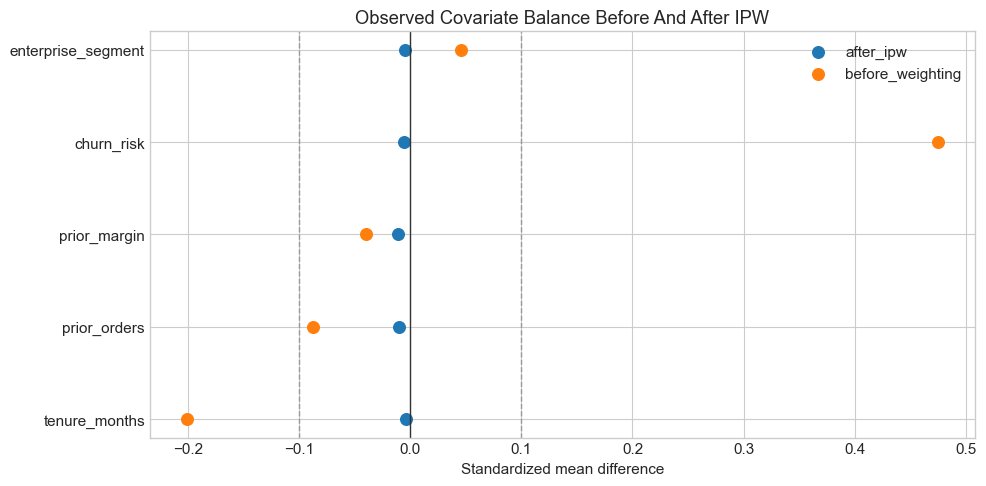

In [10]:
plot_balance = balance_df.melt(id_vars="feature", var_name="stage", value_name="std_mean_difference")

fig, ax = plt.subplots(figsize=(10, 5))
for stage, group_df in plot_balance.groupby("stage"):
    ax.scatter(group_df["std_mean_difference"], group_df["feature"], label=stage, s=70)
ax.axvline(0, color="#333333", linewidth=1)
ax.axvline(0.1, color="#999999", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#999999", linestyle="--", linewidth=1)
ax.set_title("Observed Covariate Balance Before And After IPW")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()


## Wrap-Up

Cross-sectional causal designs are useful, but they answer narrower questions
than broad MMM or geo experiments:

- Regression discontinuity estimates a local threshold effect.
- Instrumental variables estimate the effect for units whose treatment was moved
  by the instrument.
- Propensity weighting adjusts observed imbalance, not hidden targeting logic.

Students should write the estimand and the assumption beside every estimate.
